## Implementation of Linear regression using python

In [1]:
# Import the required data science libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load the primary dataset for the lab
# NOTE: This assumes 'Food_Delivery_Times.csv' is in the same directory as this notebook
df = pd.read_csv("Food_Delivery_Times.csv")

# Display the first few rows and data structure
print("First 5 rows of the DataFrame:")
print(df.head())
print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:
   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (

In [16]:
### import required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [3]:
# Check for missing values in the 'Courier_Experience_yrs' column
missing_count = df['Courier_Experience_yrs'].isnull().sum()
print(f"Missing values in 'Courier_Experience_yrs' before filling: {missing_count}")

# 1. Calculate the mean (average) of the column
mean_experience = df['Courier_Experience_yrs'].mean()

# 2. Fill the NaN values with the calculated mean
df['Courier_Experience_yrs'].fillna(mean_experience, inplace=True)

# Confirm that missing values have been handled
print("\nDataFrame Info after filling missing values:")
df.info()

Missing values in 'Courier_Experience_yrs' before filling: 0

DataFrame Info after filling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  1000 non-null   float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


C:\Users\charvib\AppData\Local\Temp\ipykernel_268\3264171209.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Courier_Experience_yrs'].fillna(mean_experience, inplace=True)


## Load the dataset

In [4]:
# Select the categorical columns mentioned in the lab and two others for a complete model
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# Perform One-Hot Encoding (creating dummy variables)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop columns that are not features or the target (like Order_ID and Courier_Experience_yrs, 
# as the lab specifies using Distance_km, Preparation_Time_min, Traffic, and Weather)
# However, we will keep all potentially useful features for a robust model.
df_encoded = df_encoded.drop(columns=['Order_ID'])

# Display the first few rows of the new encoded DataFrame
print("First 5 rows of the Encoded DataFrame:")
print(df_encoded.head())

# Display the list of new column names
print("\nNew Columns (Features) for the Model:")
print(df_encoded.columns)

First 5 rows of the Encoded DataFrame:
   Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
0         7.93                    12                     1.0   
1        16.42                    20                     2.0   
2         9.52                    28                     1.0   
3         7.44                     5                     1.0   
4        19.03                    16                     5.0   

   Delivery_Time_min  Weather_Foggy  Weather_Rainy  Weather_Snowy  \
0                 43          False          False          False   
1                 84          False          False          False   
2                 59           True          False          False   
3                 37          False           True          False   
4                 68          False          False          False   

   Weather_Windy  Traffic_Level_Low  Traffic_Level_Medium  \
0           True               True                 False   
1          False              False    

In [3]:
df1=pd.read_csv("weight-height.csv")
df1

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,169.034243,163.852461


In [5]:
# 1. Define Features (X) and Target (y)
# The target variable is 'Delivery_Time_min'
y = df_encoded['Delivery_Time_min']

# The features X are all other columns. Drop Delivery_Time_min from the features.
X = df_encoded.drop(columns=['Delivery_Time_min'])

# 2. Split the data into Training and Testing sets (80/20 split)
# We set random_state for reproducible results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

# 3. Apply Feature Scaling using MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler ONLY on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData splitting and scaling complete.")

Training set size: 800 rows
Testing set size: 200 rows

Data splitting and scaling complete.


### Standardize numerical features

In [6]:
# 1. Initialize the Linear Regression model
linear_model = LinearRegression()

# 2. Train the model using the scaled training data
# X_train_scaled contains the scaled features
# y_train contains the target (Delivery_Time_min)
linear_model.fit(X_train_scaled, y_train)

# Output confirmation
print("Linear Regression model trained successfully.")

# Print the model's intercept (c) and coefficients (m1, m2, ...)
print(f"\nModel Intercept (c): {linear_model.intercept_:.2f}")
print("Model Coefficients (m):")
# Create a DataFrame to display feature names and their corresponding coefficients
coefficients_df = pd.DataFrame(
    {'Feature': X.columns, 'Coefficient': linear_model.coef_}
)
# Sort by the absolute value of the coefficient to see the most impactful features
coefficients_df['Absolute_Coefficient'] = coefficients_df['Coefficient'].abs()
coefficients_df = coefficients_df.sort_values(by='Absolute_Coefficient', ascending=False).drop(columns=['Absolute_Coefficient'])
print(coefficients_df.to_string(index=False))

Linear Regression model trained successfully.

Model Intercept (c): 24.38
Model Coefficients (m):
               Feature  Coefficient
           Distance_km    58.210601
  Preparation_Time_min    23.166381
     Traffic_Level_Low   -10.756559
         Weather_Snowy     9.136596
Courier_Experience_yrs    -6.054830
         Weather_Foggy     5.862757
  Traffic_Level_Medium    -5.150181
         Weather_Rainy     4.629024
     Time_of_Day_Night    -2.116768
   Time_of_Day_Morning    -1.692218
         Weather_Windy     1.360946
  Vehicle_Type_Scooter    -0.942216
      Vehicle_Type_Car     0.510509
   Time_of_Day_Evening     0.277413


In [4]:
col=["Height","Weight"]
S1=MinMaxScaler()
df1[col]=S1.fit_transform(df1[col])
df1


,Gender,Height,Weight
0,Male,0.165212,0.863139
1,Male,0.122482,0.475476
2,Male,0.167432,0.721131
3,Male,0.147361,0.756699
4,Male,0.131761,0.689999
...,...,...,...
9995,Female,0.100470,0.351101
9996,Female,0.108016,0.517161
9997,Female,0.081028,0.310660
9998,Female,0.968224,0.482988


--- Model Performance Metrics ---
Mean Squared Error (MSE): 79.23
R-squared (R2) Score: 0.8232


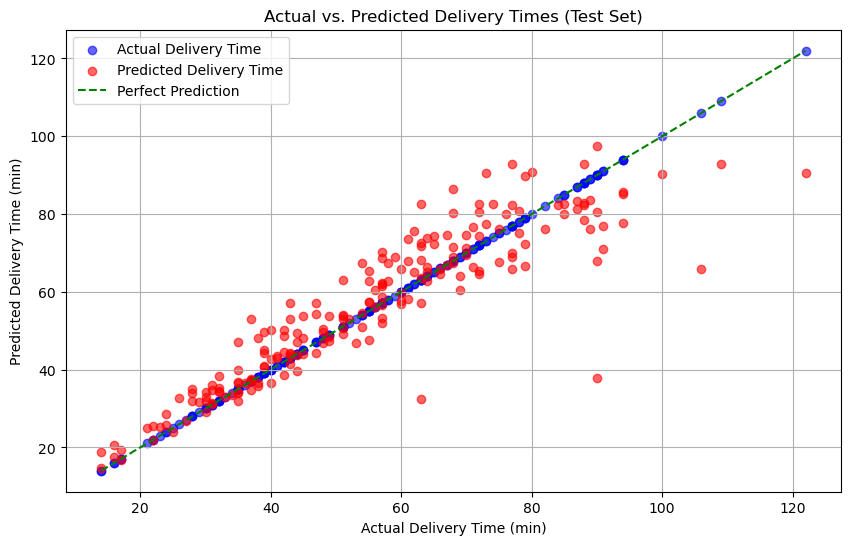

In [7]:
# 1. Make predictions on the scaled test set
y_pred = linear_model.predict(X_test_scaled)

# 2. Evaluate the model performance using common metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 3. Visualize the Actual vs. Predicted values (Plotting)
plt.figure(figsize=(10, 6))
# Plot actual values (y_test)
plt.scatter(y_test, y_test, color='blue', label='Actual Delivery Time', alpha=0.6)
# Plot predicted values (y_pred)
plt.scatter(y_test, y_pred, color='red', label='Predicted Delivery Time', alpha=0.6)
# Plot the ideal prediction line (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='green', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted Delivery Times (Test Set)')
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.legend()
plt.grid(True)
plt.show()

## Prepare dependant and independant variables

In [9]:
X=df1[["Height"]].to_numpy()
Y=df1[["Weight"]].to_numpy()
Y.shape

(10000, 1)

## Split the data into training and test set

In [10]:
 X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=.2,random_state=67)

In [11]:
# Create a linear regression model

model=LinearRegression()



Note: Learning more about Linear Regression model here: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html 



In [ ]:
## Training  Linear regressions model 

In [12]:
model.fit(X_train,Y_train)

LinearRegression()

In [14]:
## Calculating the Mean Squared Error (MSE) and R-squared (R2)
Y_pred=model.predict(X_test)

mse=mean_squared_error(Y_test,Y_pred)
r2=r2_score(Y_test,Y_pred)
print(mse)
print(r2)

# Print model coefficients
print(model.coef_[0])
print(model.intercept_)

0.0044380478890117024
0.8135299373473699
[3.54709605]
[0.10829265]


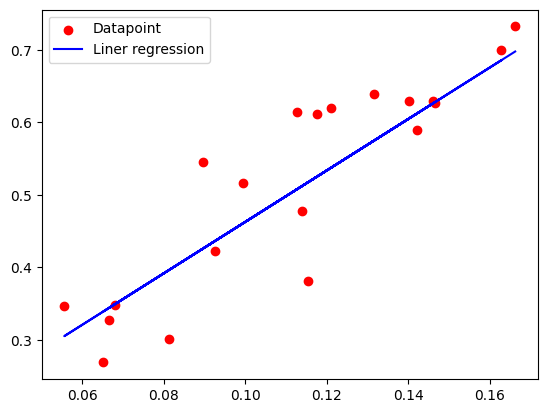

In [19]:
# Plot the linear regression Model 
plt.scatter(X_test[0:20],Y_test[0:20],color="Red",label="Datapoint")
plt.plot(X_test[0:20],Y_pred[0:20],color="Blue",label="Liner regression")
plt.legend()


In [8]:
## Load the Height and weight  to indipendent and dependent variable 

In [35]:
df2=pd.read_csv("weight-height.csv")
X = df2['Height'].values.reshape(-1, 1)
X.shape
Y=df2["Weight"].values

In [36]:
## Standardizes the features X and target variable y using Z-score normalization (also called Standardization). 
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
Y = (Y - np.mean(Y, axis=0)) / np.std(Y, axis=0)


In [37]:
#add another feature to X corresponding to bias
X = np.hstack((np.ones((X.shape[0], 1)), X))
X

array([[ 1.        ,  1.75827913],
       [ 1.        ,  0.56277158],
       [ 1.        ,  1.82037531],
       ...,
       [ 1.        , -0.59704831],
       [ 1.        , 24.22511229],
       [ 1.        , -1.05110595]])

In [46]:
#weight or parameter initialization
theta = np.zeros(X.shape[1])
iterations=1000
# Hyperparameters
learningrate=0.01
# Gradient Descent
mseh=[]
print(X.shape)
s=(y_pred - Y)
print(s.shape)
m=X.T
print(m.shape)

(10000, 2)
(10000,)
(2, 10000)


<img src="https://i.postimg.cc/wMYVXD65/1.png" alt="Image Description" width="500">

In [50]:
for i in range(iterations):
    y_pred = np.dot(X, theta) 
    mse = mean_squared_error(Y, y_pred)   
    mseh.append(mse)
    print(f"Iteration {i+1}: MSE = {mse}")
    gradient = np.dot(X.T, (y_pred - Y)) / len(Y)
    theta -= learningrate * gradient

Iteration 1: MSE = 1.0
Iteration 2: MSE = 0.9858094192775753
Iteration 3: MSE = 0.9719012311115264
Iteration 4: MSE = 0.9582698158899821
Iteration 5: MSE = 0.9449096658313463
Iteration 6: MSE = 0.9318153827588777
Iteration 7: MSE = 0.9189816759195509
Iteration 8: MSE = 0.9064033598463269
Iteration 9: MSE = 0.8940753522629601
Iteration 10: MSE = 0.881992672030502
Iteration 11: MSE = 0.87015043713467
Iteration 12: MSE = 0.8585438627132651
Iteration 13: MSE = 0.8471682591228462
Iteration 14: MSE = 0.8360190300438765
Iteration 15: MSE = 0.8250916706235785
Iteration 16: MSE = 0.8143817656557442
Iteration 17: MSE = 0.80388498779677
Iteration 18: MSE = 0.7935970958171892
Iteration 19: MSE = 0.7835139328880021
Iteration 20: MSE = 0.773631424901106
Iteration 21: MSE = 0.7639455788231488
Iteration 22: MSE = 0.7544524810821432
Iteration 23: MSE = 0.7451482959861836
Iteration 24: MSE = 0.7360292641736336
Iteration 25: MSE = 0.7270917010941532
Iteration 26: MSE = 0.7183319955199547
Iteration 27: MS

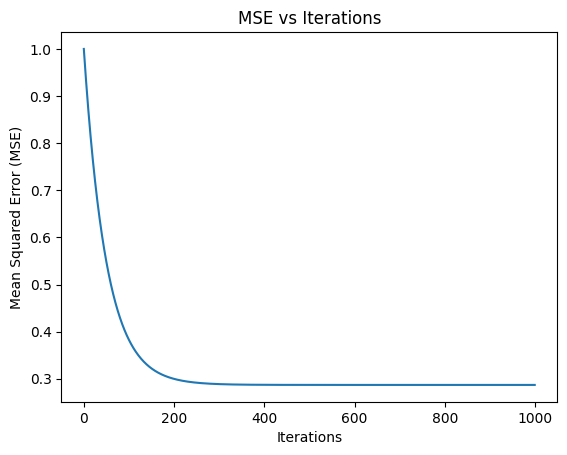

In [51]:
# Plot the MSE over iterations
plt.plot(range(iterations), mseh)
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs Iterations')
plt.show()

## You are required to fit a linear function on Food_delivery_times dataset
Description about the dataset: This dataset is designed for predicting food delivery times based on various influencing factors such as distance, weather, traffic conditions, and Preperation time. 
1. Feature selection: Consider Food_delivery_time is effected by four features (attributes) given in the dataset, which are Distance_km, Preparation_Time_min, Traffic, Weather
2. Since Traffic, Weather are having categorical values, you need to convert them into numerical using the categorical encoding methods.
3. Now, fit a linear regression model considering Distance_km, Preparation_Time_min, Traffic, and Weather as independant variables and Delivery_Time_min as dependant varibal. 


Note: In lab record, you can write the statements relevant to linear regression.